# Top 10 States Sales Analysis
In this notebook, we'll explore our sales data geographically and perform initial data cleaning.
Specifically, we visualize the top-performing states by sales revenue.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

from matplotlib.ticker import FuncFormatter, MultipleLocator

## 1. Data Integration
Loading the raw dataset and removing whitespace from column names.

In [2]:
df = pd.read_csv('../data/raw/amazon_sale_report.csv', low_memory=False)

# Remove whitespace from column names
df.columns = df.columns.str.strip()

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 2. Feature Selection
Subsetting to only relevant columns. We use `.copy()` to avoid the SettingWithCopy warning later.

In [3]:
# Keep only the relevant columns
columns_to_keep = [
    'Date', 
    'Status', 
    'Fulfilment', 
    'Sales Channel',
    'Qty',
    'Amount', 
    'ship-city', 
    'ship-state', 
    'ship-postal-code', 
    'ship-country'
]

geo_sales_df = df[columns_to_keep].copy()

geo_sales_df.info()
geo_sales_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              128975 non-null  str    
 1   Status            128975 non-null  str    
 2   Fulfilment        128975 non-null  str    
 3   Sales Channel     128975 non-null  str    
 4   Qty               128975 non-null  int64  
 5   Amount            121180 non-null  float64
 6   ship-city         128942 non-null  str    
 7   ship-state        128942 non-null  str    
 8   ship-postal-code  128942 non-null  float64
 9   ship-country      128942 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 9.8 MB


,Date,Status,Fulfilment,Sales Channel,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country
0,04-30-22,Cancelled,Merchant,Amazon.in,0,647.62,MUMBAI,MAHARASHTRA,400081.0,IN
1,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,1,406.00,BENGALURU,KARNATAKA,560085.0,IN
2,04-30-22,Shipped,Amazon,Amazon.in,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN
3,04-30-22,Cancelled,Merchant,Amazon.in,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN
4,04-30-22,Shipped,Amazon,Amazon.in,1,574.00,CHENNAI,TAMIL NADU,600073.0,IN


## 3. Preprocessing
Filtering out cancelled/pending orders, removing missing data, cleaning up text formats, and fixing data types.

In [6]:
# Filter for actual shipped orders
shipped_statuses = [
    'Shipped',
    'Shipped - Delivered to Buyer',
    'Shipped - Picked Up',
    'Shipped - Out for Delivery'
]

is_shipped = geo_sales_df['Status'].isin(shipped_statuses)
geo_sales_df = geo_sales_df[is_shipped]

# Remove rows where 'Amount' or 'ship-city' is missing
geo_sales_df.dropna(subset=["Amount", "ship-city"], inplace=True)

# Convert Date from string to proper datetime object
geo_sales_df['Date'] = pd.to_datetime(geo_sales_df['Date'])

# Convert postal code to integer first (to remove .0) and then string
geo_sales_df['ship-postal-code'] = geo_sales_df['ship-postal-code'].astype(int).astype(str)

# Clean up the city, state, and country names
geo_sales_df['ship-state'] = geo_sales_df['ship-state'].str.strip()
geo_sales_df['ship-city'] = geo_sales_df['ship-city'].str.strip()
geo_sales_df['ship-country'] = geo_sales_df['ship-country'].str.strip()

# Capitalize the city, state, and country names
geo_sales_df['ship-state'] = geo_sales_df['ship-state'].str.title()
geo_sales_df['ship-city'] = geo_sales_df['ship-city'].str.title()
geo_sales_df['ship-country'] = geo_sales_df['ship-country'].str.title()

geo_sales_df.info()
geo_sales_df.head()


<class 'pandas.DataFrame'>
Index: 107342 entries, 1 to 128974
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              107342 non-null  datetime64[us]
 1   Status            107342 non-null  str           
 2   Fulfilment        107342 non-null  str           
 3   Sales Channel     107342 non-null  str           
 4   Qty               107342 non-null  int64         
 5   Amount            107342 non-null  float64       
 6   ship-city         107342 non-null  str           
 7   ship-state        107342 non-null  str           
 8   ship-postal-code  107342 non-null  str           
 9   ship-country      107342 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 9.0 MB


,Date,Status,Fulfilment,Sales Channel,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,1,406.0,Bengaluru,Karnataka,560085,In
2,2022-04-30,Shipped,Amazon,Amazon.in,1,329.0,Navi Mumbai,Maharashtra,410210,In
4,2022-04-30,Shipped,Amazon,Amazon.in,1,574.0,Chennai,Tamil Nadu,600073,In
5,2022-04-30,Shipped,Amazon,Amazon.in,1,824.0,Ghaziabad,Uttar Pradesh,201102,In
6,2022-04-30,Shipped,Amazon,Amazon.in,1,653.0,Chandigarh,Chandigarh,160036,In


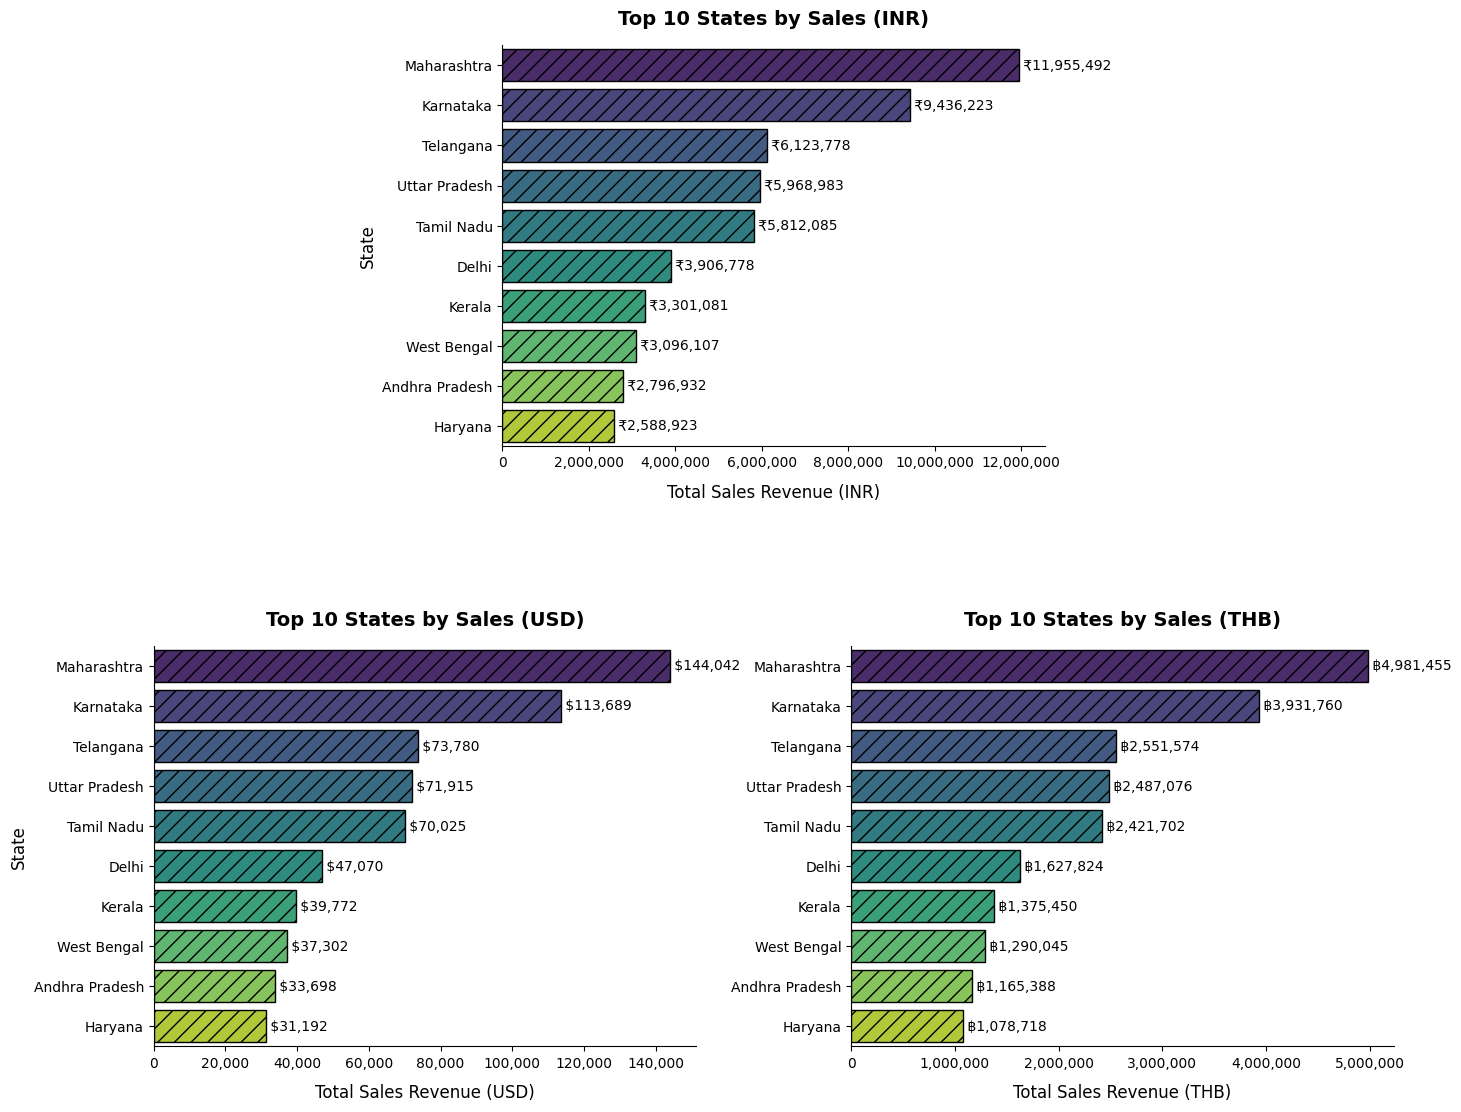

In [5]:
# Create money formatter function
def money_format(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    else:
        return f"{x:.0f}"

formatter = FuncFormatter(money_format)

# Prepare data
state_sales = (
    geo_sales_df.groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Setup a 2x4 grid
fig = plt.figure(figsize=(16, 13))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.8)

ax1 = fig.add_subplot(gs[0, 1:3]) # Top center
ax2 = fig.add_subplot(gs[1, 0:2]) # Bottom left
ax3 = fig.add_subplot(gs[1, 2:4]) # Bottom right
axes = [ax1, ax2, ax3]

currencies = [
    ('INR', 1.0, '₹'),
    ('USD', 1/83.0, '$'),
    ('THB', 1/2.4, '฿')
]

for ax, (curr, rate, symbol) in zip(axes, currencies):
    sales = state_sales * rate
    
    # Barplot with styles
    sns.barplot(
        x=sales.values, 
        y=sales.index, 
        ax=ax, 
        palette='viridis', 
        hue=sales.index,
        hatch='//', 
        edgecolor='black',
        legend=False
    )
    
    
    ax.set_title(f'Top 10 States by Sales ({curr})', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f'Total Sales Revenue ({curr})', fontsize=12, labelpad=10)
    ax.set_ylabel('State', fontsize=12) if ax in [ax1, ax2] else ax.set_ylabel('')
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    for index, value in enumerate(sales.values):
        ax.text(value, index, f' {symbol}{value:,.0f}', va='center', fontsize=10)
        
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()
